# 📊 Data Cleaning, Labelling Review & EDA (YOLOv8 Dataset)

## 1. Data Acquisition
Berdasarkan pengumpulan data yang telah dilakukan melalui REST API, berikut adalah profil dataset yang digunakan dalam proyek deteksi kondisi fisik kartu:

* **Sumber Dataset**: Roboflow Universe (Workspace: `group-6-major-project`, Project: `card-grader`, Version: 4)
* **Lisensi**: CC BY 4.0
* **Jumlah Kelas**: 4 Kelas
* **Daftar Kelas**: `['Card', 'Corner Wear', 'Edge Wear', 'Scratch']`
* **Format**: YOLOv8 PyTorch

In [1]:
import os
import glob
import cv2
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Path dataset
dataset_path = "../dataset/card-condition-dataset"
classes = ['Card', 'Corner Wear', 'Edge Wear', 'Scratch']

In [2]:
print("--- Memulai Proses Data Cleaning ---")
all_images = glob.glob(f"{dataset_path}/*/images/*.jpg")
print(f"Total gambar yang dipindai: {len(all_images)}")

corrupt_files = []
small_resolution_files = []
image_hashes = {}
duplicates = []
resolutions = []

for img_path in all_images:
    try:
        with Image.open(img_path) as img:
            img.verify()  # Mengecek apakah file korup
            
        # Buka ulang untuk mengecek ukuran (karena verify() menutup stream)
        with Image.open(img_path) as img:
            w, h = img.size
            resolutions.append(f"{w}x{h}")
            if w < 100 or h < 100:
                small_resolution_files.append(img_path)
                
            # Mengecek duplikasi dengan SHA256 Hash
            img_byte = img.tobytes()
            img_hash = hashlib.sha256(img_byte).hexdigest()
            if img_hash in image_hashes:
                duplicates.append(img_path)
            else:
                image_hashes[img_hash] = img_path
                
    except Exception as e:
        corrupt_files.append(img_path)

print(f"✅ File Korup ditemukan       : {len(corrupt_files)}")
print(f"✅ File Duplikat ditemukan    : {len(duplicates)}")
print(f"✅ Resolusi Terlalu Kecil (<100px) : {len(small_resolution_files)}")

# Menampilkan distribusi resolusi yang ada
res_series = pd.Series(resolutions).value_counts()
print("\nDistribusi Resolusi Gambar:")
res_series.head()

--- Memulai Proses Data Cleaning ---
Total gambar yang dipindai: 1250
✅ File Korup ditemukan       : 0
✅ File Duplikat ditemukan    : 0
✅ Resolusi Terlalu Kecil (<100px) : 0

Distribusi Resolusi Gambar:


294x416    775
296x416    475
Name: count, dtype: int64

C:\Users\THIN 15\AppData\Local\Temp\ipykernel_16636\2861928918.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=classes, y=list(class_counts.values()), palette="magma")


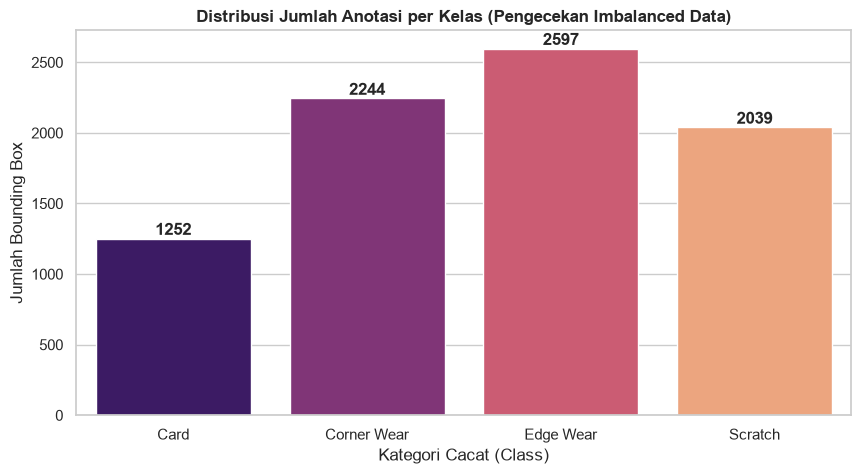

Analisis Imbalance: Jika ada kelas yang jumlahnya jauh lebih sedikit, pertimbangkan teknik augmentasi gambar untuk kelas minoritas tersebut.


In [3]:
all_labels = glob.glob(f"{dataset_path}/*/labels/*.txt")
class_counts = {i: 0 for i in range(len(classes))}

for label_path in all_labels:
    with open(label_path, 'r') as file:
        lines = file.readlines()
        for line in lines:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

# Visualisasi Distribusi Kelas
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=classes, y=list(class_counts.values()), palette="magma")
plt.title("Distribusi Jumlah Anotasi per Kelas (Pengecekan Imbalanced Data)", fontweight="bold")
plt.xlabel("Kategori Cacat (Class)")
plt.ylabel("Jumlah Bounding Box")

# Menambahkan angka di atas bar
for i, v in enumerate(class_counts.values()):
    ax.text(i, v + max(class_counts.values())*0.01, str(v), ha='center', fontweight='bold')

plt.show()

print("Analisis Imbalance: Jika ada kelas yang jumlahnya jauh lebih sedikit, pertimbangkan teknik augmentasi gambar untuk kelas minoritas tersebut.")

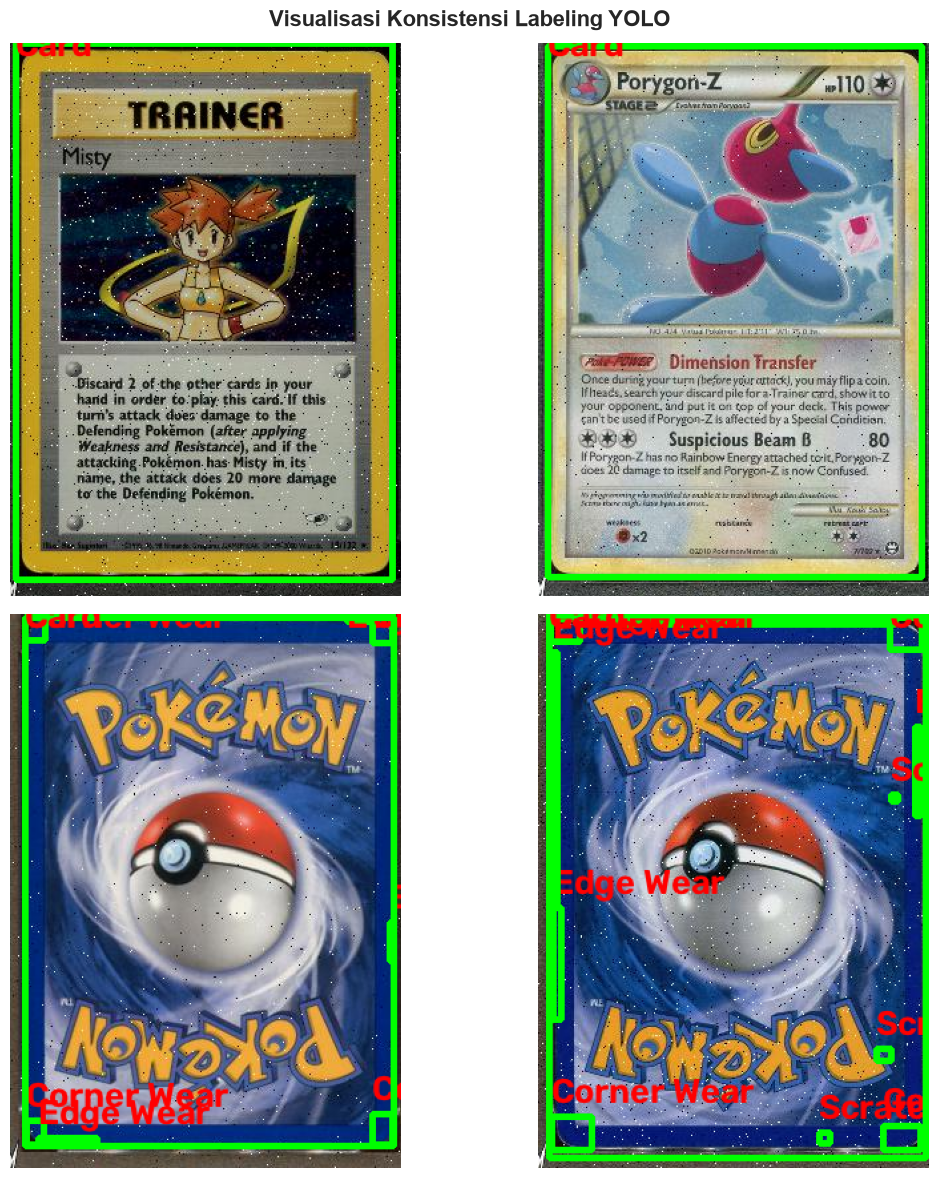

In [4]:
import random

def draw_yolo_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                data = line.strip().split()
                class_id = int(data[0])
                # YOLO format: x_center, y_center, width, height (normalized)
                x_center, y_center, width, height = map(float, data[1:])
                
                # Konversi ke koordinat piksel
                x1 = int((x_center - width/2) * w)
                y1 = int((y_center - height/2) * h)
                x2 = int((x_center + width/2) * w)
                y2 = int((y_center + height/2) * h)
                
                # Menggambar kotak
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
                cv2.putText(img, classes[class_id], (x1, max(y1-10, 10)), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
    return img

# Mengambil 4 sampel acak dari data training
train_images = glob.glob(f"{dataset_path}/train/images/*.jpg")
sample_images = random.sample(train_images, min(4, len(train_images)))

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle("Visualisasi Konsistensi Labeling YOLO", fontsize=16, fontweight="bold")

for i, img_path in enumerate(sample_images):
    label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
    img_with_boxes = draw_yolo_boxes(img_path, label_path)
    
    ax = axes[i//2, i%2]
    ax.imshow(img_with_boxes)
    ax.axis('off')

plt.tight_layout()
plt.show()

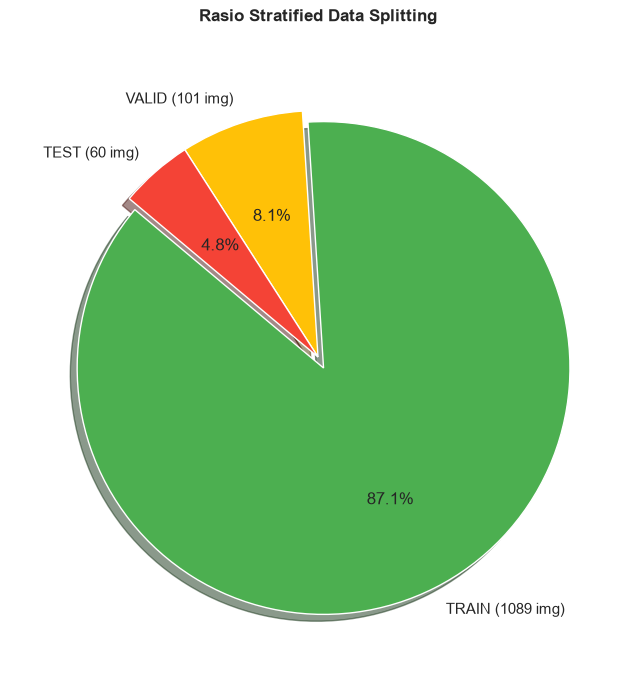

Total gambar dalam dataset Model: 1250


In [5]:
splits = ['train', 'valid', 'test']
split_counts = {}

for split in splits:
    split_images = glob.glob(f"{dataset_path}/{split}/images/*.jpg")
    split_counts[split] = len(split_images)

total_split = sum(split_counts.values())

# Visualisasi Rasio Data Splitting
plt.figure(figsize=(8, 8))
plt.pie(split_counts.values(), labels=[f"{k.upper()} ({v} img)" for k, v in split_counts.items()], 
        autopct='%1.1f%%', startangle=140, colors=['#4CAF50', '#FFC107', '#F44336'], 
        explode=(0.05, 0, 0), shadow=True)
plt.title("Rasio Stratified Data Splitting", fontweight="bold", pad=20)
plt.show()

print(f"Total gambar dalam dataset Model: {total_split}")